# Setup and Imports


In [ ]:
# Run this cell first in every notebook
import os
import sys

sys.path.append(os.path.abspath('../src'))

%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np

from demodulator import (
    downconvert_to_baseband,
    load_mono_normalized_audio,
    locate_pilot_start,
    matched_filter_sync,
    slice_pilot_samples,
)
from modulator import map_bits_to_symbols
from plot_utils import plot_complex_parts, plot_correlation_response
from sync import generate_zadoff_chu_audio
import config


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# System Parameters


In [ ]:
# Match these exactly to TX.
FS = config.FS
F_CARRIER = config.F_CARRIER
SYMBOL_RATE = config.SYMBOL_RATE
SAMPLES_PER_SYMBOL = config.SAMPLES_PER_SYMBOL
ZC_ROOT = config.u_zadoff_chu
ZC_LENGTH = config.len_zadoff_chu
SYNC_GAP_SECONDS = 0

rx_path = '../data/tx_single_carrier_test.wav'


# Load and Downconvert Audio


In [17]:
fs, rx_audio = load_mono_normalized_audio(rx_path)
if fs != FS:
    raise ValueError(f'Expected sample rate {FS}, got {fs}')

rx_baseband = downconvert_to_baseband(
    rx_audio=rx_audio,
    fs=FS,
    carrier_freq=F_CARRIER,
    cutoff_hz=SYMBOL_RATE,
    filter_order=5,
)


# Synchronization


In [18]:
reference_zc = generate_zadoff_chu_audio(ZC_LENGTH, ZC_ROOT)
zc_start_idx, corr = matched_filter_sync(rx_baseband, reference_zc)

pilot_start_idx = locate_pilot_start(
    sync_start_idx=zc_start_idx,
    sync_length=ZC_LENGTH,
    fs=FS,
    gap_seconds=SYNC_GAP_SECONDS,
)

print('-' * 50)
print(f'Zadoff-Chu peak found at sample index: {zc_start_idx}')
print(f'Known pilots begin at sample index: {pilot_start_idx}')
print('-' * 50)


--------------------------------------------------
Zadoff-Chu peak found at sample index: 240000
Known pilots begin at sample index: 240353
--------------------------------------------------


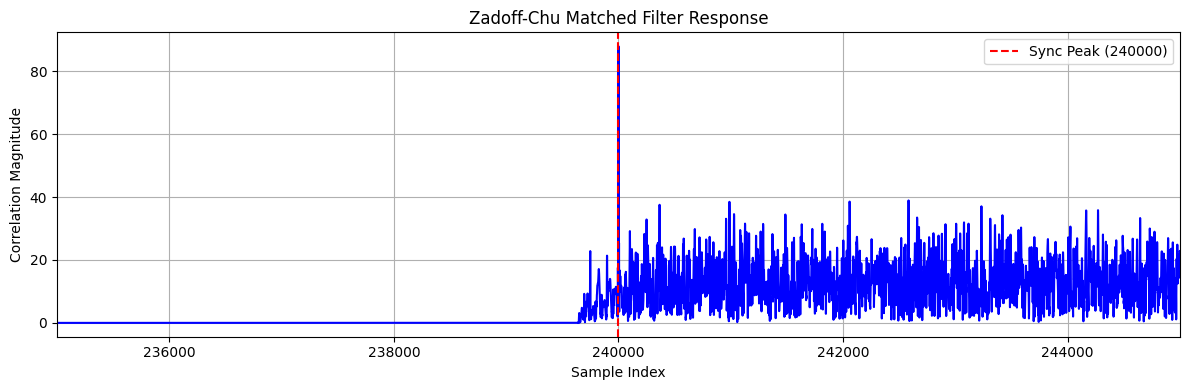

In [19]:
plot_correlation_response(corr, zc_start_idx)
plt.show()


# Pilot Extraction


In [20]:
pilot_bits = [0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0]
pilot_symbols = map_bits_to_symbols(pilot_bits, 4, METHOD="QAM")
KNOWN_PILOT_SYMBOLS = pilot_symbols

rx_pilots = slice_pilot_samples(
    rx_baseband=rx_baseband,
    pilot_start_idx=pilot_start_idx,
    num_pilot_symbols=len(KNOWN_PILOT_SYMBOLS),
    samples_per_symbol=SAMPLES_PER_SYMBOL,
)


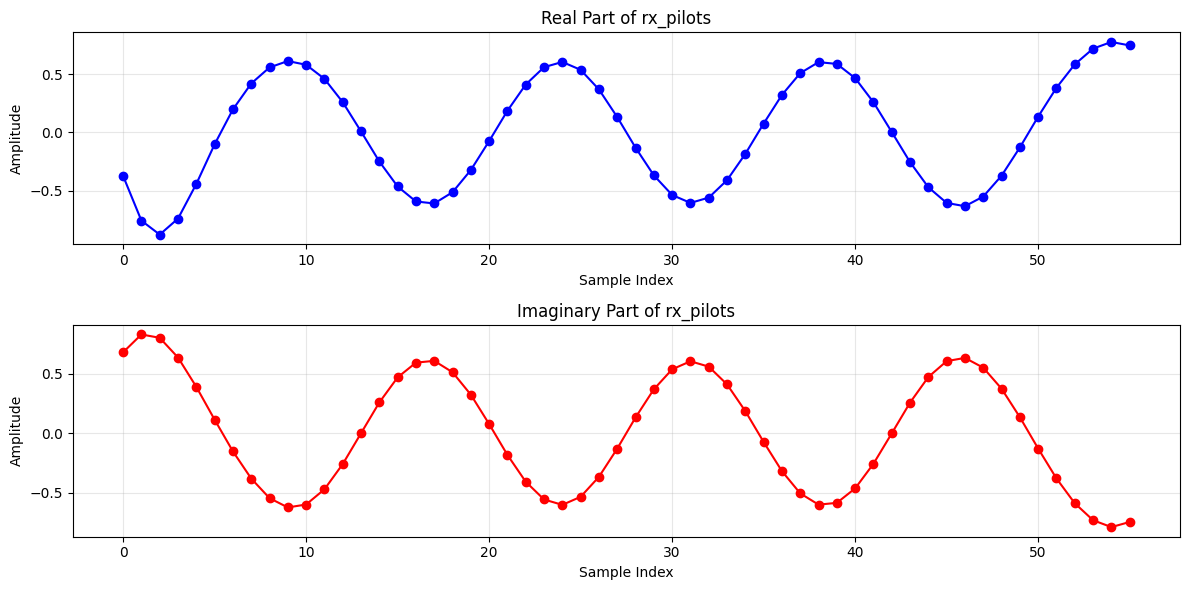

In [21]:
plot_complex_parts(rx_pilots, title_prefix='rx_pilots')
plt.show()
